# COPD Risk Finder: Exploratory Data Analysis

**Dataset**: GSK Simulated EHR (`data/raw/`)  

**Target**: Spirometry-derived label: `min(FEV1/FVC) < 0.70` per patient

**Note on `epoc_diagnostico`**: Kept as a comparison variable only. It encodes physician-recorded diagnosis, which reflects the underdiagnosis problem this tool is designed to solve. It is **not** used as the model target.

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Quality](#2)
3. [Label Derivation: Spirometry Gold Standard](#3)
4. [Selection Bias: Who Has Spirometry?](#4)
5. [Demographics](#5)
6. [Smoking & Lifestyle Habits](#6)
7. [Lab Results](#7)
8. [Spirometry: Longitudinal Feature Engineering](#8)
9. [Clinical Events (ICD-10 Comorbidities)](#9)
10. [Clinical Notes - NLP](#10)
11. [Bivariate Correlations with Label](#11)
12. [Outlier Analysis: Lab Values](#12)
13. [Key Findings & Modelling Implications](#13)


---
## 1. Setup & Data Loading <a id='1'></a>

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('../data/raw')
THRESHOLD = 0.70          # GOLD FEV1/FVC obstruction threshold
COPD_COLORS = ['#4CAF50', '#E53935']   # 0 = no COPD (green), 1 = COPD (red)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
print('Libraries loaded.')

Libraries loaded.


In [68]:
# ── Load all tables ────────────────────────────────────────────────────────
patients   = pd.read_csv(DATA_DIR / 'patients.csv')
habits     = pd.read_csv(DATA_DIR / 'habits.csv')
labs       = pd.read_csv(DATA_DIR / 'lab_results.csv')
spirometry = pd.read_csv(DATA_DIR / 'spirometry.csv', parse_dates=['fecha'])
events     = pd.read_csv(DATA_DIR / 'clinical_events.csv', parse_dates=['fecha'])
notes      = pd.read_csv(DATA_DIR / 'clinical_notes.csv')
target_raw = pd.read_csv(DATA_DIR / 'target.csv')   # administrative diagnosis, comparison only

for name, df in [('patients', patients), ('habits', habits), ('labs', labs),
                  ('spirometry', spirometry), ('events', events),
                  ('notes', notes), ('target_raw', target_raw)]:
    print(f'{name:<15}: {df.shape[0]:>6,} rows × {df.shape[1]} cols')

patients       : 10,000 rows × 6 cols
habits         : 10,000 rows × 5 cols
labs           : 10,000 rows × 7 cols
spirometry     : 20,068 rows × 5 cols
events         : 12,073 rows × 3 cols
notes          : 10,000 rows × 2 cols
target_raw     : 10,000 rows × 2 cols


---
## 2. Data Quality <a id='2'></a>

In [69]:
# ── Missing values ─────────────────────────────────────────────────────────
print("Missing values per table:")
for name, df in [('patients', patients), ('habits', habits), ('labs', labs),
                  ('spirometry', spirometry), ('events', events), ('target_raw', target_raw)]:
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if miss.empty:
        print(f"  {name:<15}: no missing values")
    else:
        pct = (miss / len(df) * 100).round(1)
        for col in miss.index:
            print(f"  {name:<15}: {col}: {miss[col]:,} missing ({pct[col]}%)")

Missing values per table:
  patients       : no missing values
  habits         : no missing values
  labs           : grupo_sanguineo: 970 missing (9.7%)
  labs           : vitamina_d_ng_ml: 1,028 missing (10.3%)
  labs           : colesterol_total_mg_dl: 1,023 missing (10.2%)
  labs           : ferritina_ng_ml: 970 missing (9.7%)
  labs           : tsh_ui_ml: 932 missing (9.3%)
  labs           : pcr_mg_l: 1,003 missing (10.0%)
  spirometry     : no missing values
  events         : no missing values
  target_raw     : no missing values


In [70]:
# ── Spirometry data quality flags ─────────────────────────────────────────
# FEV1/FVC > 1.0 is physically impossible and indicates recording errors
impossible = spirometry[spirometry['fev1_fvc_ratio'] > 1.0]
print(f"Spirometry rows with FEV1/FVC > 1.0 (impossible): {len(impossible):,}")
print(f"  Affects {impossible['id_paciente'].nunique():,} unique patients")
if len(impossible) > 0:
    print(f"  Max observed ratio: {spirometry['fev1_fvc_ratio'].max():.3f}")
    print(impossible[['id_paciente','fecha','fev1','fvc','fev1_fvc_ratio']].head(10).to_string(index=False))

# FEV1 > FVC is also problematic
inconsistent_fef = spirometry[spirometry['fev1'] > spirometry['fvc']]
print(f"\nSpiometry rows with FEV1 > FVC (inconsistent): {len(inconsistent_fef):,}")

# Outlier ratios near 0
very_low = spirometry[spirometry['fev1_fvc_ratio'] < 0.20]
print(f"Spirometry rows with FEV1/FVC < 0.20 (extreme obstruction / noise): {len(very_low):,}")

Spirometry rows with FEV1/FVC > 1.0 (impossible): 355
  Affects 345 unique patients
  Max observed ratio: 1.650
 id_paciente      fecha  fev1  fvc  fev1_fvc_ratio
           8 2021-01-30  1.09 1.00            1.09
          48 2023-04-13  1.89 1.71            1.10
          51 2020-01-18  2.51 2.36            1.06
         127 2022-10-19  1.83 1.79            1.02
         196 2022-02-24  1.69 1.49            1.14
         197 2022-12-24  1.22 1.05            1.16
         200 2020-06-04  1.92 1.88            1.02
         210 2021-12-21  1.52 1.36            1.11
         212 2021-12-01  2.08 1.98            1.05
         259 2023-03-03  2.53 2.45            1.03

Spiometry rows with FEV1 > FVC (inconsistent): 367
Spirometry rows with FEV1/FVC < 0.20 (extreme obstruction / noise): 1


In [71]:
# ── Flag and exclude impossible spirometry rows before label derivation ───
# Keep only rows where 0.10 <= FEV1/FVC <= 1.0
spirometry_clean = spirometry[(spirometry['fev1_fvc_ratio'] <= 1.0) &
                               (spirometry['fev1_fvc_ratio'] >= 0.10)].copy()

n_removed = len(spirometry) - len(spirometry_clean)
print(f"Removed {n_removed:,} rows with impossible FEV1/FVC values.")
print(f"Clean spirometry: {len(spirometry_clean):,} rows, {spirometry_clean['id_paciente'].nunique():,} patients")

Removed 355 rows with impossible FEV1/FVC values.
Clean spirometry: 19,713 rows, 9,948 patients


---
## 3. Label Derivation: Spirometry Gold Standard <a id='3'></a>

**Clinical rationale**: COPD is defined by persistent airflow obstruction (GOLD 2024).  
Criterion: **FEV1/FVC < 0.70** (post-bronchodilator in clinical practice; pre-bronchodilator here, as that is what the dataset contains).

**Label rule**: A patient is labelled COPD-positive if their **minimum FEV1/FVC ratio across all clean spirometry tests** is below 0.70.  

The minimum is used because COPD is irreversible: if any valid test showed obstruction, the disease was present.


In [72]:
# ── Aggregate spirometry to one row per patient ────────────────────────────
spiro_agg = (
    spirometry_clean
    .sort_values(['id_paciente', 'fecha'])
    .groupby('id_paciente')
    .agg(
        spiro_min_ratio    = ('fev1_fvc_ratio', 'min'),
        spiro_max_ratio    = ('fev1_fvc_ratio', 'max'),
        spiro_mean_ratio   = ('fev1_fvc_ratio', 'mean'),
        spiro_latest_ratio = ('fev1_fvc_ratio', 'last'),
        spiro_first_ratio  = ('fev1_fvc_ratio', 'first'),
        spiro_mean_fev1    = ('fev1', 'mean'),
        spiro_min_fev1     = ('fev1', 'min'),
        spiro_mean_fvc     = ('fvc', 'mean'),
        spiro_n_tests      = ('fev1_fvc_ratio', 'count'),
        spiro_first_date   = ('fecha', 'first'),
        spiro_last_date    = ('fecha', 'last'),
    )
    .reset_index()
)

# ── Time span and slope features ──────────────────────────────────────────
spiro_agg['spiro_years_span'] = (
    (spiro_agg['spiro_last_date'] - spiro_agg['spiro_first_date']).dt.days / 365.25
)

# Slope: change in FEV1/FVC per year (only meaningful with 2+ tests)
spiro_agg['spiro_slope'] = np.where(
    (spiro_agg['spiro_n_tests'] >= 2) & (spiro_agg['spiro_years_span'] > 0),
    (spiro_agg['spiro_latest_ratio'] - spiro_agg['spiro_first_ratio']) / spiro_agg['spiro_years_span'],
    np.nan
)

# ── Derive label ───────────────────────────────────────────────────────────
spiro_agg['copd_label'] = (spiro_agg['spiro_min_ratio'] < THRESHOLD).astype(int)

print(f"Patients with spirometry records : {len(spiro_agg):,}")
print(f"\nNew label (copd_label) distribution:")
vc = spiro_agg['copd_label'].value_counts().sort_index()
for val, cnt in vc.items():
    print(f"  {'COPD' if val else 'No COPD'} ({val}): {cnt:,} ({cnt/len(spiro_agg)*100:.1f}%)")

Patients with spirometry records : 9,948

New label (copd_label) distribution:
  No COPD (0): 2,348 (23.6%)
  COPD (1): 7,600 (76.4%)


In [73]:
# ── Compare new label vs. administrative diagnosis ─────────────────────────
label_compare = spiro_agg[['id_paciente','copd_label']].merge(
    target_raw, on='id_paciente', how='inner'
)

agree = (label_compare['copd_label'] == label_compare['epoc_diagnostico']).mean() * 100

# Build 2x2 table
ct = pd.crosstab(
    label_compare['copd_label'],
    label_compare['epoc_diagnostico'],
    rownames=['Spirometry label'],
    colnames=['Admin diagnosis']
)
ct.index = ['Spiro: No COPD','Spiro: COPD']
ct.columns = ['Admin: No COPD','Admin: COPD']

print(f"Agreement between spirometry label and admin diagnosis: {agree:.1f}%")
print()
print(ct)
print()

# Cells of interest
n_spiro_pos  = label_compare['copd_label'].sum()
n_admin_pos  = label_compare['epoc_diagnostico'].sum()
# Spirometry says COPD, admin says no = undiagnosed
n_undiagnosed = ((label_compare['copd_label']==1) & (label_compare['epoc_diagnostico']==0)).sum()
# Admin says COPD, spirometry says no = questionable diagnosis
n_questionable = ((label_compare['copd_label']==0) & (label_compare['epoc_diagnostico']==1)).sum()

print(f"Spirometry-confirmed COPD         : {n_spiro_pos:,}")
print(f"Administratively diagnosed COPD   : {n_admin_pos:,}")
print(f"Undiagnosed (spiro+, admin-)       : {n_undiagnosed:,}  ← these are who we want to find")
print(f"Questionable (spiro-, admin+)      : {n_questionable:,}  ← possible false diagnoses or missing spiro data")

Agreement between spirometry label and admin diagnosis: 28.9%

                Admin: No COPD  Admin: COPD
Spiro: No COPD            2293           55
Spiro: COPD               7016          584

Spirometry-confirmed COPD         : 7,600
Administratively diagnosed COPD   : 639
Undiagnosed (spiro+, admin-)       : 7,016  ← these are who we want to find
Questionable (spiro-, admin+)      : 55  ← possible false diagnoses or missing spiro data


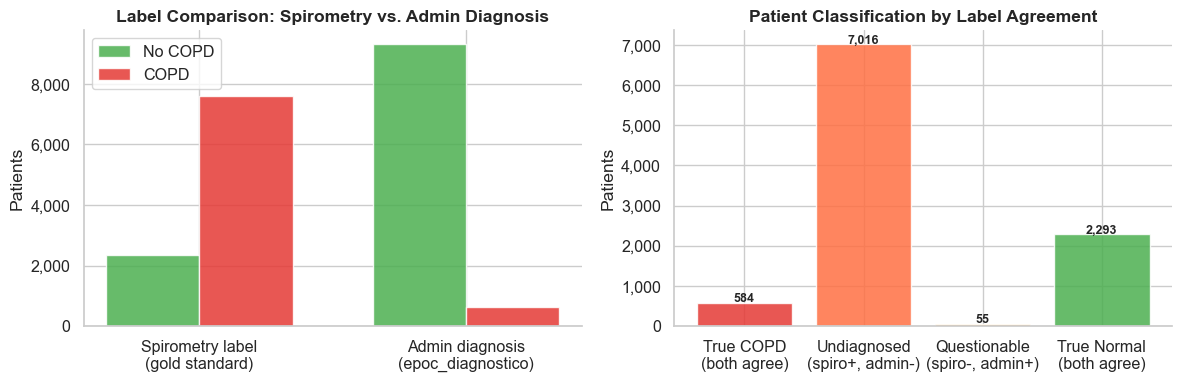

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: bar comparison of both labels
bars_data = {
    'Spirometry label\n(gold standard)': [len(label_compare) - n_spiro_pos, n_spiro_pos],
    'Admin diagnosis\n(epoc_diagnostico)': [len(label_compare) - n_admin_pos, n_admin_pos],
}
x = np.arange(2)
w = 0.35
axes[0].bar(x - w/2, [v[0] for v in bars_data.values()], w, label='No COPD', color='#4CAF50', alpha=0.85)
axes[0].bar(x + w/2, [v[1] for v in bars_data.values()], w, label='COPD', color='#E53935', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(list(bars_data.keys()))
axes[0].set_title('Label Comparison: Spirometry vs. Admin Diagnosis', fontweight='bold')
axes[0].set_ylabel('Patients')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: Venn-style breakdown
categories = ['True COPD\n(both agree)', 'Undiagnosed\n(spiro+, admin-)', 'Questionable\n(spiro-, admin+)', 'True Normal\n(both agree)']
n_true_copd    = ((label_compare['copd_label']==1) & (label_compare['epoc_diagnostico']==1)).sum()
n_true_normal  = ((label_compare['copd_label']==0) & (label_compare['epoc_diagnostico']==0)).sum()
values = [n_true_copd, n_undiagnosed, n_questionable, n_true_normal]
colors = ['#E53935','#FF7043','#FFA726','#4CAF50']
axes[1].bar(categories, values, color=colors, alpha=0.85, edgecolor='white')
for i, v in enumerate(values):
    axes[1].text(i, v + 20, f'{v:,}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Patient Classification by Label Agreement', fontweight='bold')
axes[1].set_ylabel('Patients')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

sns.despine()
plt.tight_layout()
plt.show()

In [75]:
# ── Patients with multiple tests crossing the 0.70 threshold ──────────────
# These are patients who had at least one test above AND one below 0.70
threshold_crossers = spiro_agg[
    (spiro_agg['spiro_n_tests'] >= 2) &
    (spiro_agg['spiro_min_ratio'] < THRESHOLD) &
    (spiro_agg['spiro_max_ratio'] >= THRESHOLD)
]
print(f"Patients who cross the 0.70 threshold across tests: {len(threshold_crossers):,}")
print(f"  (had both a normal and an obstructive reading, which confirms using MIN ratio is correct)")
print()
print("Examples:")
ex = threshold_crossers.merge(target_raw, on='id_paciente').head(5)
print(ex[['id_paciente','spiro_min_ratio','spiro_max_ratio','spiro_n_tests',
           'spiro_slope','copd_label','epoc_diagnostico']].to_string(index=False))

Patients who cross the 0.70 threshold across tests: 3,888
  (had both a normal and an obstructive reading, which confirms using MIN ratio is correct)

Examples:
 id_paciente  spiro_min_ratio  spiro_max_ratio  spiro_n_tests  spiro_slope  copd_label  epoc_diagnostico
           2             0.61             0.71              2     0.185406           1                 0
           4             0.44             1.00              3     0.520458           1                 0
           6             0.49             0.75              3     0.162890           1                 0
           7             0.59             0.75              2     0.358528           1                 0
           9             0.46             0.76              3    -0.077199           1                 0


---
## 4. Selection Bias: Who Has Spirometry? <a id='4'></a>

Patients **with spirometry** form the training population. Patients **without spirometry** cannot receive a label.  
If the two groups differ systematically, the model will be trained on a non-representative population. This is a known selection bias; it must be characterised and reported.


In [76]:
# ── Build two groups ──────────────────────────────────────────────────────
patients_with_spiro = set(spirometry_clean['id_paciente'])

all_patients = (
    patients
    .merge(habits, on='id_paciente', how='left')
    .merge(labs,   on='id_paciente', how='left')
    .merge(target_raw, on='id_paciente', how='left')
)
all_patients['has_spirometry'] = all_patients['id_paciente'].isin(patients_with_spiro).astype(int)

n_with    = all_patients['has_spirometry'].sum()
n_without = len(all_patients) - n_with

print(f"Total patients        : {len(all_patients):,}")
print(f"With spirometry       : {n_with:,} ({n_with/len(all_patients)*100:.1f}%) → training population")
print(f"Without spirometry    : {n_without:,} ({n_without/len(all_patients)*100:.1f}%) → inference target (real-world use case)")

Total patients        : 10,000
With spirometry       : 9,948 (99.5%) → training population
Without spirometry    : 52 (0.5%) → inference target (real-world use case)


In [77]:
# ── Compare the two groups on key clinical variables ──────────────────────
compare_cols = ['edad','imc','paquetes_ano','fumador_actual','exfumador','pcr_mg_l','epoc_diagnostico']
compare_cols = [c for c in compare_cols if c in all_patients.columns]

comparison = all_patients.groupby('has_spirometry')[compare_cols].agg(['mean','median']).round(2)
comparison.index = ['No spirometry','Has spirometry']

print("Clinical comparison: patients with vs. without spirometry")
print(comparison.to_string())
print()
print("Interpretation: if 'Has spirometry' group is older, sicker, or more likely smokers,")
print("the training set is biased toward higher-risk patients.")

Clinical comparison: patients with vs. without spirometry
                 edad           imc        paquetes_ano        fumador_actual        exfumador        pcr_mg_l        epoc_diagnostico       
                 mean median   mean median         mean median           mean median      mean median     mean median             mean median
No spirometry   64.25   62.0  26.88  26.85         7.81    0.8           0.38    0.0      0.12    0.0     2.83   2.17             0.10    0.0
Has spirometry  67.37   67.0  27.04  27.00         7.84    0.0           0.32    0.0      0.17    0.0     3.02   2.56             0.06    0.0

Interpretation: if 'Has spirometry' group is older, sicker, or more likely smokers,
the training set is biased toward higher-risk patients.


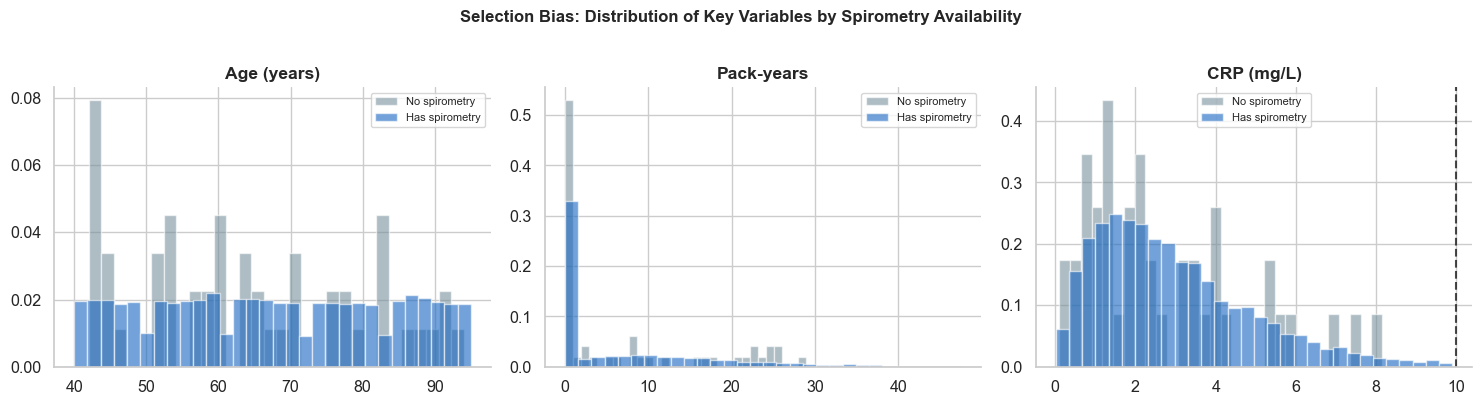

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sel_vars = [
    ('edad',        'Age (years)',     None),
    ('paquetes_ano','Pack-years',      None),
    ('pcr_mg_l',    'CRP (mg/L)',      10),
]
group_colors = ['#78909C','#1565C0']

for ax, (col, label, threshold) in zip(axes, sel_vars):
    for val, color, grp_label in zip([0,1], group_colors, ['No spirometry','Has spirometry']):
        data = all_patients[all_patients['has_spirometry'] == val][col].dropna()
        p99 = data.quantile(0.99)
        ax.hist(data[data <= p99], bins=30, alpha=0.6, color=color, label=grp_label, edgecolor='white', density=True)
    if threshold:
        ax.axvline(threshold, color='black', linestyle='--', alpha=0.7)
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8)

sns.despine()
plt.suptitle('Selection Bias: Distribution of Key Variables by Spirometry Availability',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [79]:
# ── Admin diagnosis rate in each group ────────────────────────────────────
admin_rate = all_patients.groupby('has_spirometry')['epoc_diagnostico'].mean() * 100
admin_rate.index = ['No spirometry','Has spirometry']
print("Admin COPD diagnosis rate by group:")
print(admin_rate.round(1))
print()
print("If the 'Has spirometry' group has a much higher admin diagnosis rate,")
print("it confirms that spirometry is ordered preferentially for suspected/known cases.")

Admin COPD diagnosis rate by group:
No spirometry     9.6
Has spirometry    6.4
Name: epoc_diagnostico, dtype: float64

If the 'Has spirometry' group has a much higher admin diagnosis rate,
it confirms that spirometry is ordered preferentially for suspected/known cases.


---
## 5. Demographics <a id='5'></a>

All analyses from this point use `copd_label` (spirometry-derived) and are restricted to patients with spirometry records.

In [80]:
# ── Build analysis dataset: patients with spirometry only ─────────────────
analysis = (
    patients
    .merge(habits,    on='id_paciente', how='inner')
    .merge(labs,      on='id_paciente', how='inner')
    .merge(spiro_agg, on='id_paciente', how='inner')   # inner = only patients with spirometry
    .merge(target_raw, on='id_paciente', how='left')    # keep admin diagnosis for reference
)

print(f"Analysis dataset: {len(analysis):,} patients (those with spirometry)")
print(f"COPD label distribution:")
vc = analysis['copd_label'].value_counts().sort_index()
for k, v in vc.items():
    print(f"  {'COPD' if k else 'No COPD'}: {v:,} ({v/len(analysis)*100:.1f}%)")

Analysis dataset: 9,948 patients (those with spirometry)
COPD label distribution:
  No COPD: 2,348 (23.6%)
  COPD: 7,600 (76.4%)


             count  mean   std   min   25%   50%   75%   max
copd_label                                                  
No COPD     2348.0  63.6  16.0  40.0  50.0  61.0  77.0  95.0
COPD        7600.0  68.5  16.0  40.0  55.0  69.0  83.0  95.0


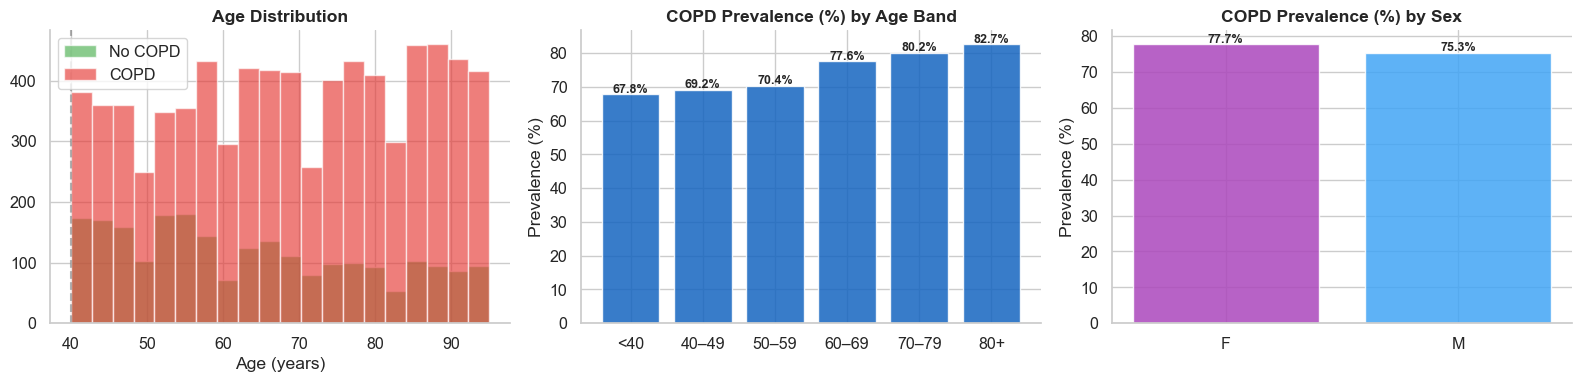

In [81]:
# ── Age ───────────────────────────────────────────────────────────────────
print(analysis.groupby('copd_label')['edad'].describe().round(1).rename(index={0:'No COPD',1:'COPD'}))

analysis['age_band'] = pd.cut(analysis['edad'],
    bins=[0,40,50,60,70,80,120], labels=['<40','40–49','50–59','60–69','70–79','80+'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age histogram
for val, color, lbl in zip([0,1], COPD_COLORS, ['No COPD','COPD']):
    axes[0].hist(analysis[analysis['copd_label']==val]['edad'], bins=20,
                 alpha=0.65, color=color, label=lbl, edgecolor='white')
axes[0].axvline(40, color='gray', linestyle='--', alpha=0.6)
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].legend()

# Prevalence by age band
prev_age = analysis.groupby('age_band')['copd_label'].mean() * 100
axes[1].bar(prev_age.index, prev_age.values, color='#1565C0', edgecolor='white', alpha=0.85)
for i, v in enumerate(prev_age.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('COPD Prevalence (%) by Age Band', fontweight='bold')
axes[1].set_ylabel('Prevalence (%)')

# Sex × COPD
sex_copd = analysis.groupby('sexo')['copd_label'].agg(['mean','count'])
sex_copd['prevalence_%'] = (sex_copd['mean'] * 100).round(1)
axes[2].bar(sex_copd.index, sex_copd['prevalence_%'], color=['#AB47BC','#42A5F5'], edgecolor='white', alpha=0.85)
for i, (idx, row) in enumerate(sex_copd.iterrows()):
    axes[2].text(i, row['prevalence_%'] + 0.5, f"{row['prevalence_%']:.1f}%", ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('COPD Prevalence (%) by Sex', fontweight='bold')
axes[2].set_ylabel('Prevalence (%)')

sns.despine()
plt.tight_layout()
plt.show()

---
## 6. Smoking & Lifestyle Habits <a id='6'></a>

Smoking is the primary modifiable risk factor for COPD, and physical inactivity is both a contributor and a consequence. This section examines their distribution across the spirometry-confirmed population and their association with the label.


In [82]:
analysis['ever_smoked'] = ((analysis['fumador_actual']==1) | (analysis['exfumador']==1)).astype(int)

# Prevalence by smoking group
smoke_groups = {
    'Never':   analysis[(analysis['fumador_actual']==0) & (analysis['exfumador']==0)],
    'Ex':      analysis[analysis['exfumador']==1],
    'Current': analysis[analysis['fumador_actual']==1],
}
print("COPD prevalence by smoking status:")
for k, v in smoke_groups.items():
    prev = v['copd_label'].mean() * 100
    print(f"  {k:<10}: {prev:.1f}%  (n= {len(v):,})")

COPD prevalence by smoking status:
  Never     : 72.8%  (n= 5,030)
  Ex        : 78.8%  (n= 1,717)
  Current   : 80.7%  (n= 3,201)


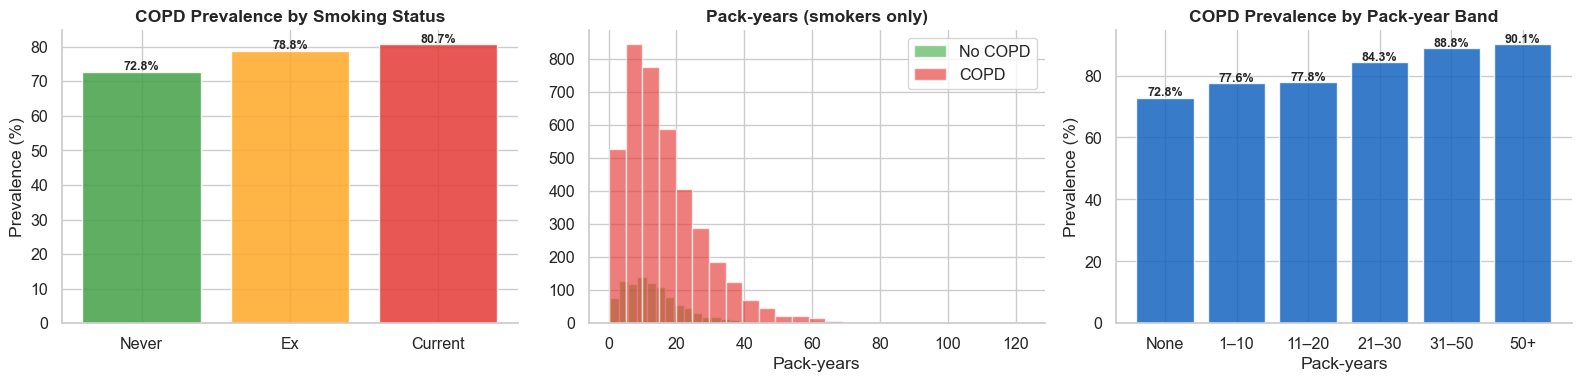

In [83]:
analysis['packyear_band'] = pd.cut(analysis['paquetes_ano'],
    bins=[-1,0,10,20,30,50,500], labels=['None','1–10','11–20','21–30','31–50','50+'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Smoking status prevalence bar
prev_smoke = {k: v['copd_label'].mean()*100 for k,v in smoke_groups.items()}
axes[0].bar(prev_smoke.keys(), prev_smoke.values(),
            color=['#43A047','#FFA726','#E53935'], edgecolor='white', alpha=0.85)
for i, (k,v) in enumerate(prev_smoke.items()):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
axes[0].set_title('COPD Prevalence by Smoking Status', fontweight='bold')
axes[0].set_ylabel('Prevalence (%)')

# Pack-years histogram
for val, color, lbl in zip([0,1], COPD_COLORS, ['No COPD','COPD']):
    data = analysis[(analysis['copd_label']==val) & (analysis['paquetes_ano']>0)]['paquetes_ano']
    axes[1].hist(data, bins=25, alpha=0.65, color=color, label=lbl, edgecolor='white')
axes[1].set_title('Pack-years (smokers only)', fontweight='bold')
axes[1].set_xlabel('Pack-years')
axes[1].legend()

# Prevalence by pack-year band
prev_py = analysis.groupby('packyear_band')['copd_label'].mean() * 100
axes[2].bar(prev_py.index, prev_py.values, color='#1565C0', edgecolor='white', alpha=0.85)
for i, v in enumerate(prev_py.values):
    axes[2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('COPD Prevalence by Pack-year Band', fontweight='bold')
axes[2].set_ylabel('Prevalence (%)')
axes[2].set_xlabel('Pack-years')

sns.despine()
plt.tight_layout()
plt.show()

---
## 7. Lab Results <a id='7'></a>

Five continuous lab markers are available: CRP, Vitamin D, total cholesterol, ferritin, and TSH. This section examines their distributions, checks for extreme values, and assesses their association with COPD status.


In [84]:
lab_cols = ['pcr_mg_l','vitamina_d_ng_ml','colesterol_total_mg_dl','ferritina_ng_ml','tsh_ui_ml']

print("Median lab values by COPD label:")
print(analysis.groupby('copd_label')[lab_cols].median().round(2).rename(index={0:'No COPD',1:'COPD'}).T)

Median lab values by COPD label:
copd_label              No COPD    COPD
pcr_mg_l                   2.55    2.56
vitamina_d_ng_ml          24.40   24.00
colesterol_total_mg_dl   188.80  188.60
ferritina_ng_ml          118.90  119.00
tsh_ui_ml                  2.08    2.09


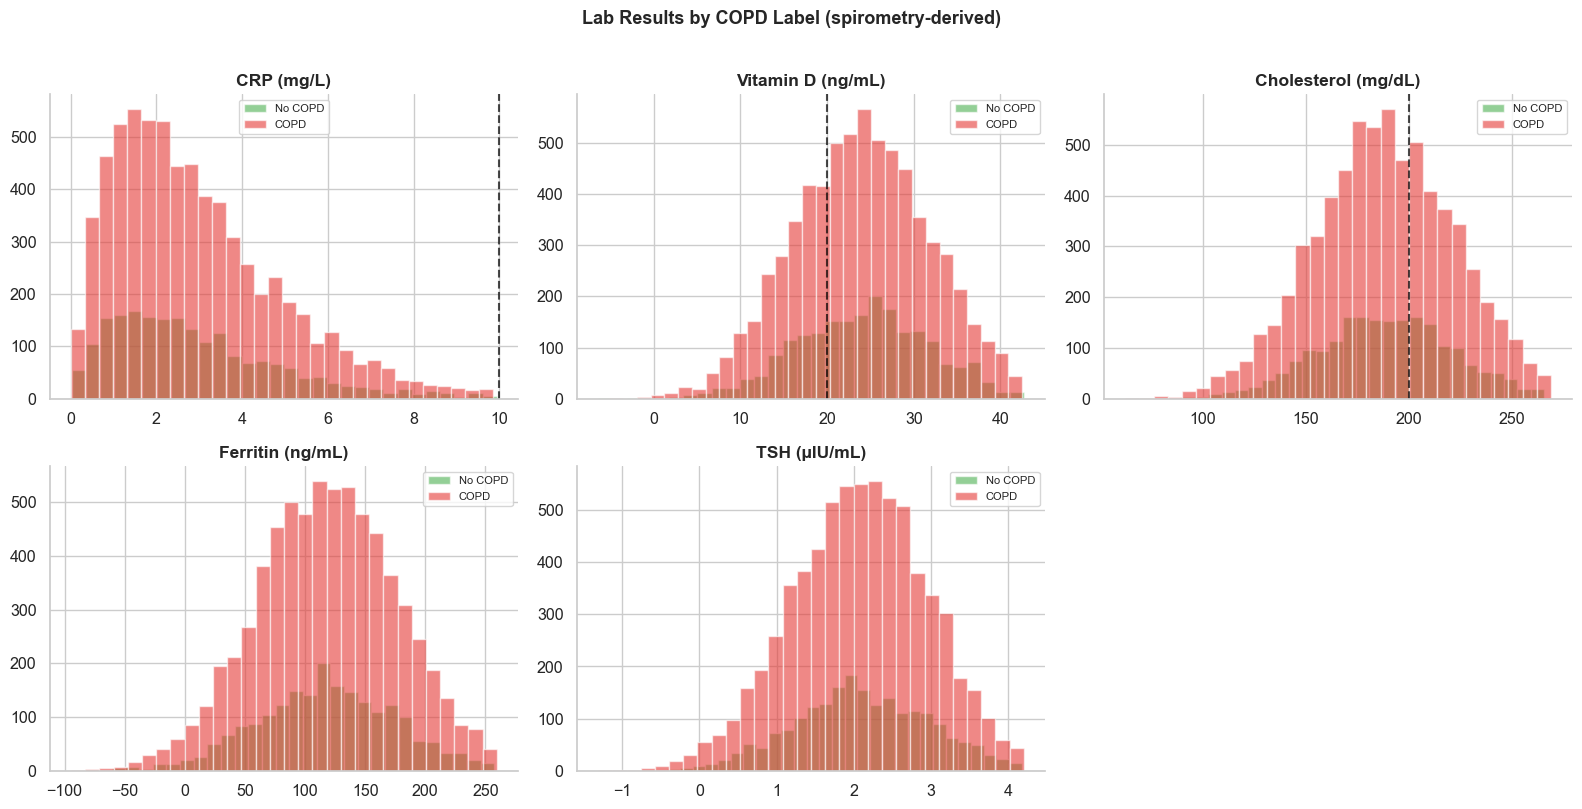

In [85]:
lab_meta = [
    ('pcr_mg_l',               'CRP (mg/L)',              10),
    ('vitamina_d_ng_ml',       'Vitamin D (ng/mL)',       20),
    ('colesterol_total_mg_dl', 'Cholesterol (mg/dL)',     200),
    ('ferritina_ng_ml',        'Ferritin (ng/mL)',        None),
    ('tsh_ui_ml',              'TSH (µIU/mL)',            None),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (col, label, threshold) in enumerate(lab_meta):
    ax = axes[i]
    for val, color, lbl in zip([0,1], COPD_COLORS, ['No COPD','COPD']):
        data = analysis[analysis['copd_label']==val][col].dropna()
        data = data[data <= data.quantile(0.99)]
        ax.hist(data, bins=30, alpha=0.6, color=color, label=lbl, edgecolor='white')
    if threshold:
        ax.axvline(threshold, color='black', linestyle='--', alpha=0.7)
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
sns.despine()
plt.suptitle('Lab Results by COPD Label (spirometry-derived)', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Spirometry: Longitudinal Feature Engineering <a id='8'></a>

Spirometry provides the most direct measure of airflow obstruction. Because patients have multiple tests over time, we derive longitudinal features: the most recent ratio, the rate of decline (slope), and the number of tests per patient.


In [86]:
print("Spirometry aggregate features by COPD label:")
spiro_feature_cols = ['spiro_min_ratio','spiro_max_ratio','spiro_mean_ratio','spiro_latest_ratio',
                      'spiro_mean_fev1','spiro_mean_fvc','spiro_n_tests','spiro_years_span']
print(analysis.groupby('copd_label')[spiro_feature_cols].median().round(3)
      .rename(index={0:'No COPD',1:'COPD'}).T)

Spirometry aggregate features by COPD label:
copd_label          No COPD   COPD
spiro_min_ratio       0.750  0.550
spiro_max_ratio       0.800  0.700
spiro_mean_ratio      0.780  0.630
spiro_latest_ratio    0.780  0.630
spiro_mean_fev1       2.120  1.555
spiro_mean_fvc        2.696  2.440
spiro_n_tests         1.000  2.000
spiro_years_span      0.000  1.109


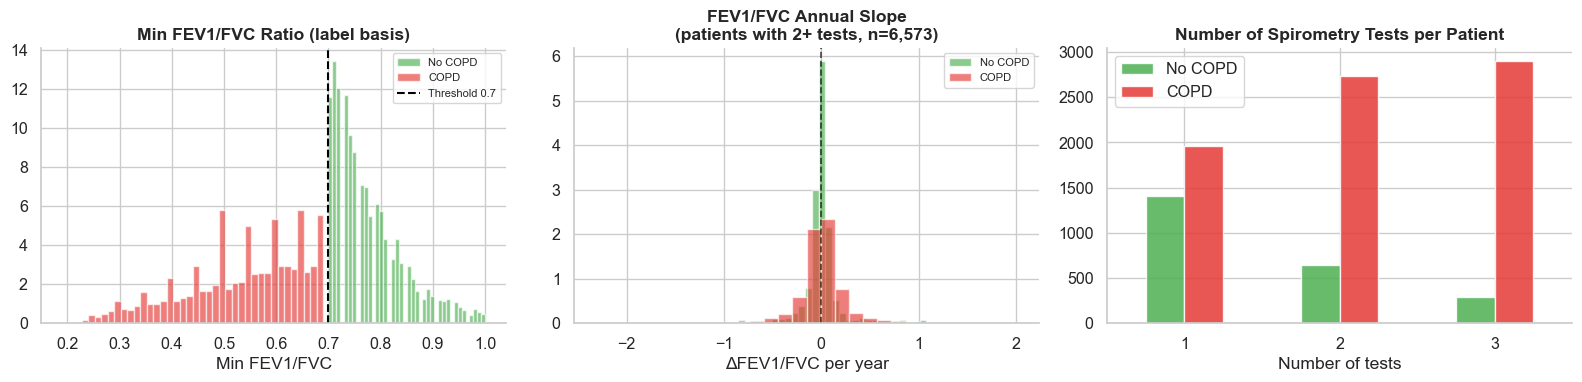

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Min ratio distribution
for val, color, lbl in zip([0,1], COPD_COLORS, ['No COPD','COPD']):
    axes[0].hist(analysis[analysis['copd_label']==val]['spiro_min_ratio'],
                 bins=40, alpha=0.65, color=color, label=lbl, edgecolor='white', density=True)
axes[0].axvline(THRESHOLD, color='black', linestyle='--', lw=1.5, label=f'Threshold {THRESHOLD}')
axes[0].set_title('Min FEV1/FVC Ratio (label basis)', fontweight='bold')
axes[0].set_xlabel('Min FEV1/FVC')
axes[0].legend(fontsize=8)

# Slope distribution (patients with 2+ tests)
slope_data = analysis[analysis['spiro_n_tests'] >= 2].dropna(subset=['spiro_slope'])
for val, color, lbl in zip([0,1], COPD_COLORS, ['No COPD','COPD']):
    data = slope_data[slope_data['copd_label']==val]['spiro_slope']
    data = data[(data >= data.quantile(0.01)) & (data <= data.quantile(0.99))]
    axes[1].hist(data, bins=30, alpha=0.65, color=color, label=lbl, edgecolor='white', density=True)
axes[1].axvline(0, color='black', linestyle='--', lw=1.2, alpha=0.7)
axes[1].set_title(f'FEV1/FVC Annual Slope\n(patients with 2+ tests, n={len(slope_data):,})', fontweight='bold')
axes[1].set_xlabel('ΔFEV1/FVC per year')
axes[1].legend(fontsize=8)

# Number of tests
n_tests_copd = analysis.groupby(['spiro_n_tests','copd_label']).size().unstack(fill_value=0)
n_tests_copd.plot(kind='bar', ax=axes[2], color=COPD_COLORS, edgecolor='white', alpha=0.85)
axes[2].set_title('Number of Spirometry Tests per Patient', fontweight='bold')
axes[2].set_xlabel('Number of tests')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
axes[2].legend(['No COPD','COPD'])

sns.despine()
plt.tight_layout()
plt.show()

In [88]:
# ── Slope by COPD label (median + IQR) ────────────────────────────────────
slope_summary = slope_data.groupby('copd_label')['spiro_slope'].describe().round(4)
slope_summary.index = ['No COPD','COPD']
print("Annual FEV1/FVC slope by COPD label:")
print(slope_summary[['mean','50%','25%','75%']])
print()
print("Note: negative slope = declining lung function (expected in COPD patients)")

Annual FEV1/FVC slope by COPD label:
           mean     50%     25%     75%
No COPD  0.0124  0.0000 -0.0476  0.0432
COPD    -0.0103  0.0044 -0.0967  0.1053

Note: negative slope = declining lung function (expected in COPD patients)


---
## 9. Clinical Events (ICD-10 Comorbidities) <a id='9'></a>

COPD rarely occurs in isolation. This section examines the ICD-10 codes recorded in `clinical_events.csv`, their frequency in the population, and their co-occurrence rates with the spirometry-derived label.


In [89]:
ICD10_MAP = {
    'J44': 'COPD (J44)',
    'J45': 'Asthma (J45)',
    'I10': 'Hypertension (I10)',
    'E11': 'Type 2 Diabetes (E11)',
    'I25': 'Ischaemic Heart Disease (I25)',
    'F32': 'Depression (F32)',
}

# Restrict events to patients in analysis set
events_analysis = events[events['id_paciente'].isin(analysis['id_paciente'])]

# Code frequency
print("ICD-10 event frequency (analysis population):")
print(events_analysis['cie10'].value_counts())

# One-hot pivot
event_onehot = (
    events_analysis
    .groupby(['id_paciente','cie10'])
    .size()
    .unstack(fill_value=0)
    .clip(upper=1)
    .reset_index()
)
event_onehot.columns.name = None

ICD-10 event frequency (analysis population):
cie10
I10    2992
J45    2399
E11    1796
I25    1784
J44    1771
F32    1272
Name: count, dtype: int64


In [90]:
# ── COPD prevalence conditioned on each comorbidity ───────────────────────
# IMPORTANT: J44 is excluded; it is equivalent to the admin diagnosis (leakage risk)
event_with_label = event_onehot.merge(analysis[['id_paciente','copd_label']], on='id_paciente', how='inner')

comorbidities = [c for c in ICD10_MAP.keys() if c != 'J44' and c in event_with_label.columns]

rows = []
for code in comorbidities:
    with_c    = event_with_label[event_with_label[code]==1]
    without_c = event_with_label[event_with_label[code]==0]
    rows.append({
        'ICD10': code,
        'Condition': ICD10_MAP[code],
        'n_patients': len(with_c),
        'COPD_prev_with_%':    round(with_c['copd_label'].mean()*100, 1),
        'COPD_prev_without_%': round(without_c['copd_label'].mean()*100, 1),
    })

comorb_df = pd.DataFrame(rows)
comorb_df['Absolute_increase_%'] = comorb_df['COPD_prev_with_%'] - comorb_df['COPD_prev_without_%']
print("COPD prevalence by comorbidity presence (using spirometry label):")
print(comorb_df.to_string(index=False))

COPD prevalence by comorbidity presence (using spirometry label):
ICD10                     Condition  n_patients  COPD_prev_with_%  COPD_prev_without_%  Absolute_increase_%
  J45                  Asthma (J45)        2123              76.0                 76.4                 -0.4
  I10            Hypertension (I10)        2586              76.1                 76.4                 -0.3
  E11         Type 2 Diabetes (E11)        1637              76.8                 76.2                  0.6
  I25 Ischaemic Heart Disease (I25)        1628              76.7                 76.2                  0.5
  F32              Depression (F32)        1187              74.2                 76.8                 -2.6


---
## 10. Clinical Notes: NLP <a id='10'></a>

Free-text clinical notes often contain symptom mentions that structured fields miss. This section applies keyword matching to `clinical_notes.csv` to extract respiratory symptom flags and checks their association with COPD status.


In [91]:
KEYWORD_PATTERNS = {
    'kw_dyspnea':      r'disnea|ahogo|falta de aire',
    'kw_cough':        r'tos(?! ferina)',
    'kw_sputum':       r'esputo|expectoraci[oó]n|mucosidad',
    'kw_exacerbation': r'exacerbaci[oó]n|agudizaci[oó]n|empeoramiento',
    'kw_breathless':   r'dificultad respiratoria|disnea de esfuerzo',
    'kw_no_symptoms':  r'sin s[ií]ntomas|asintom[aá]tico',
    'kw_wheezing':     r'sibilancias|pitidos',
    'kw_smoking':      r'fumador|tabaco|exfumador',
    'kw_copd_mention': r'epoc|obstructiva cr[oó]nica',
}

notes_clean = notes[notes['id_paciente'].isin(analysis['id_paciente'])].copy()
notes_clean['nota_lower'] = notes_clean['nota_clinica'].str.lower().fillna('')

for col, pattern in KEYWORD_PATTERNS.items():
    notes_clean[col] = notes_clean['nota_lower'].str.contains(pattern, regex=True, na=False).astype(int)

kw_cols = list(KEYWORD_PATTERNS.keys())
notes_clean['keyword_score'] = notes_clean[kw_cols].sum(axis=1)
notes_with_label = notes_clean.merge(analysis[['id_paciente','copd_label']], on='id_paciente', how='inner')

kw_by_label = notes_with_label.groupby('copd_label')[kw_cols].mean() * 100
kw_by_label.index = ['No COPD','COPD']

print("Keyword hit rate (%) by COPD label:")
print(kw_by_label.T.round(1))

Keyword hit rate (%) by COPD label:
                 No COPD  COPD
kw_dyspnea          30.5  29.5
kw_cough             0.0   0.0
kw_sputum            0.0   0.0
kw_exacerbation     25.2  25.4
kw_breathless       30.5  29.5
kw_no_symptoms      29.4  25.5
kw_wheezing          0.0   0.0
kw_smoking          41.8  51.8
kw_copd_mention      0.0   0.0


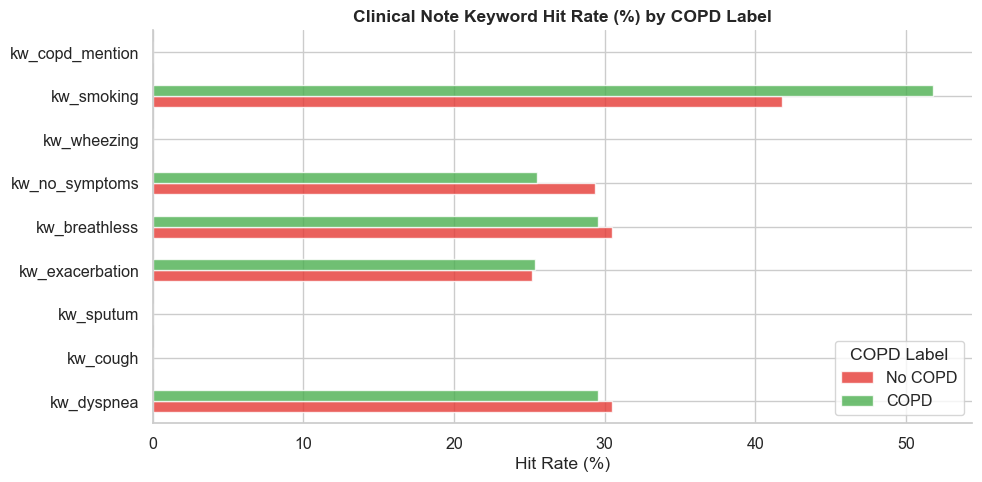

In [92]:
kw_by_label.T.plot(kind='barh', figsize=(10, 5), color=COPD_COLORS[::-1], edgecolor='white', alpha=0.8)
plt.title('Clinical Note Keyword Hit Rate (%) by COPD Label', fontweight='bold')
plt.xlabel('Hit Rate (%)')
plt.legend(title='COPD Label')
sns.despine()
plt.tight_layout()
plt.show()

---
## 11. Bivariate Correlations with Label <a id='11'></a>

Pearson correlation coefficient (r) between each numeric feature and `copd_label`. When the target is binary, this is equivalent to the point-biserial correlation. Three purposes: screen for predictive signal before modelling, flag potential leakage (|r| > 0.7 warrants investigation), and confirm that known risk factors behave as expected.

| |r| range | Interpretation |
|---|---|
| 0.00 - 0.10 | Negligible: unlikely to contribute on its own |
| 0.10 - 0.30 | Weak: may contribute in combination with other features |
| 0.30 - 0.50 | Moderate: clinically meaningful signal |
| > 0.50      | Strong: high-value predictor (verify for leakage) |

**Limitations**: Pearson r only captures linear associations. A variable can be highly predictive through a nonlinear or threshold effect yet show a low r here. Correlations are computed individually and do not capture interactions. Final feature importance should be assessed with SHAP values during the modelling phase.


In [93]:
# ── Build flat feature table ───────────────────────────────────────────────
# Aggregate events
events_flat = events_analysis.groupby('id_paciente').agg(
    n_events     = ('cie10','count'),
    n_unique_diag= ('cie10','nunique')
).reset_index()
for code in ['J45','I10','E11','I25','F32']:   # J44 EXCLUDED (leakage)
    pts = events_analysis[events_analysis['cie10']==code]['id_paciente'].unique()
    events_flat[f'has_{code.lower()}'] = events_flat['id_paciente'].isin(pts).astype(int)

# NLP features
nlp_flat = notes_clean[['id_paciente','keyword_score'] + kw_cols]

flat = (
    analysis
    .merge(events_flat, on='id_paciente', how='left')
    .merge(nlp_flat,    on='id_paciente', how='left')
)

print(f"Full feature table: {flat.shape}")

Full feature table: (9948, 51)


In [94]:
# ── Correlations with copd_label ──────────────────────────────────────────
exclude = ['id_paciente','copd_label','epoc_diagnostico',
           'spiro_first_date','spiro_last_date','age_band','packyear_band',
           'sexo','actividad_fisica','nivel_socioeconomico','zona_residencia','grupo_sanguineo']
num_cols = [c for c in flat.select_dtypes(include='number').columns if c not in exclude]

corrs = flat[num_cols + ['copd_label']].corr()['copd_label'].drop('copd_label')
corrs = corrs.sort_values(key=abs, ascending=False)

print("Top 20 features by |correlation| with copd_label:")
print(corrs.head(20).round(3))

Top 20 features by |correlation| with copd_label:
spiro_min_ratio      -0.706
spiro_mean_ratio     -0.624
spiro_min_fev1       -0.521
spiro_first_ratio    -0.507
spiro_latest_ratio   -0.491
spiro_mean_fev1      -0.432
spiro_max_ratio      -0.352
spiro_n_tests         0.315
spiro_years_span      0.239
spiro_mean_fvc       -0.171
edad                  0.128
paquetes_ano          0.104
ever_smoked           0.085
kw_smoking            0.085
fumador_actual        0.070
kw_no_symptoms       -0.037
exfumador             0.026
has_f32              -0.022
keyword_score         0.021
n_unique_diag        -0.015
Name: copd_label, dtype: float64


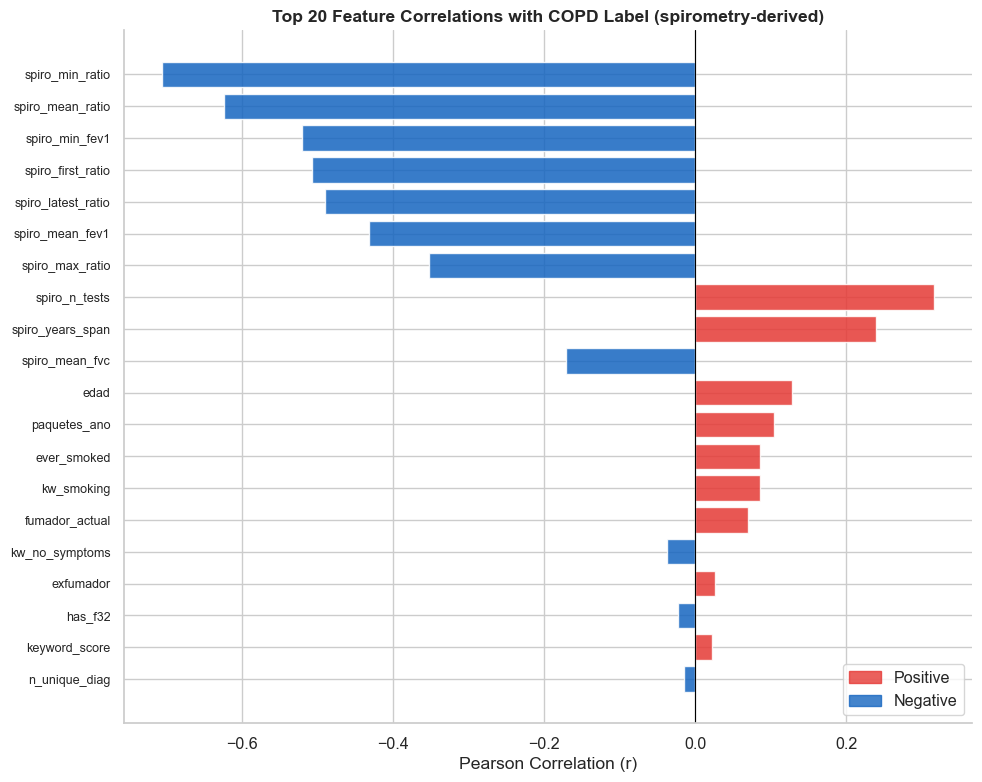

In [95]:
fig, ax = plt.subplots(figsize=(10, 8))
top = corrs.head(20)
colors = ['#E53935' if v > 0 else '#1565C0' for v in top.values]
ax.barh(range(len(top)), top.values, color=colors, edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Feature Correlations with COPD Label (spirometry-derived)',
             fontweight='bold')
ax.set_xlabel('Pearson Correlation (r)')
ax.invert_yaxis()
red  = plt.Rectangle((0,0),1,1, color='#E53935', alpha=0.8, label='Positive')
blue = plt.Rectangle((0,0),1,1, color='#1565C0', alpha=0.8, label='Negative')
ax.legend(handles=[red, blue], loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

In [96]:
# ── Leakage check: correlation of epoc_diagnostico and J44 with label ─────
if 'epoc_diagnostico' in flat.columns:
    r_admin = flat['epoc_diagnostico'].corr(flat['copd_label'])
    print(f"Correlation: epoc_diagnostico ↔ copd_label = {r_admin:.3f}")
    print("  → If this is high, admin diagnosis partially captures spirometry truth.")
    print("  → It must still be excluded from model features (post-hoc recording, not pre-screening info).")

# J44 also excluded
if 'J44' in event_onehot.columns:
    j44_flat = event_onehot[['id_paciente','J44']].merge(flat[['id_paciente','copd_label']], on='id_paciente')
    r_j44 = j44_flat['J44'].corr(j44_flat['copd_label'])
    print(f"\nCorrelation: J44 ICD code ↔ copd_label = {r_j44:.3f}")
    print("  → J44 is the administrative encoding of the same diagnosis. MUST be excluded.")

Correlation: epoc_diagnostico ↔ copd_label = 0.093
  → If this is high, admin diagnosis partially captures spirometry truth.
  → It must still be excluded from model features (post-hoc recording, not pre-screening info).

Correlation: J44 ICD code ↔ copd_label = -0.007
  → J44 is the administrative encoding of the same diagnosis. MUST be excluded.


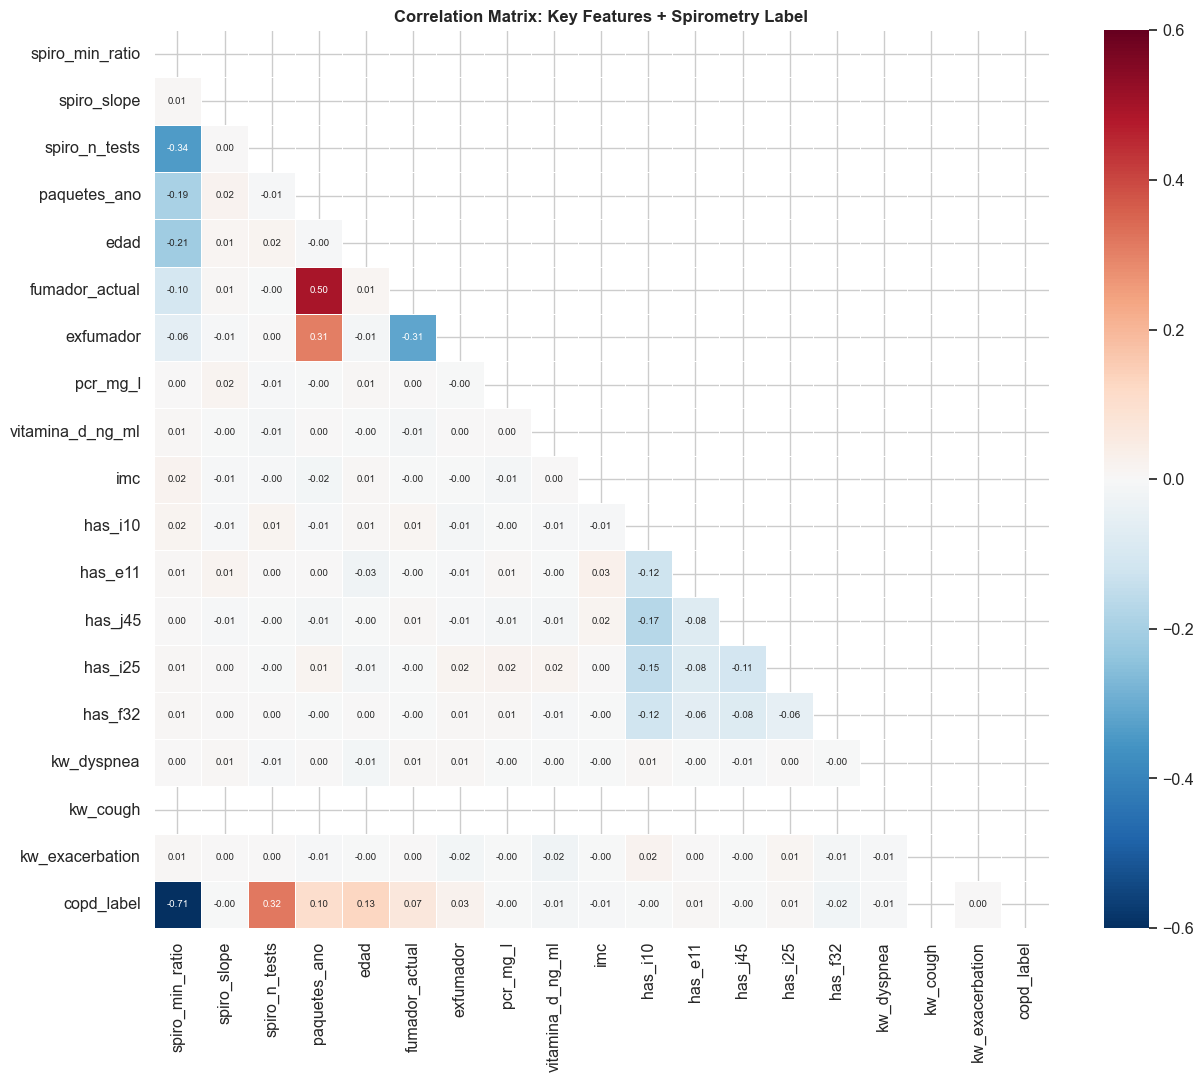

In [97]:
# ── Correlation heatmap ────────────────────────────────────────────────────
heatmap_cols = [
    'spiro_min_ratio','spiro_slope','spiro_n_tests',
    'paquetes_ano','edad','fumador_actual','exfumador',
    'pcr_mg_l','vitamina_d_ng_ml','imc',
    'has_i10','has_e11','has_j45','has_i25','has_f32',
    'kw_dyspnea','kw_cough','kw_exacerbation',
    'copd_label'
]
heatmap_cols = [c for c in heatmap_cols if c in flat.columns]
corr_mat = flat[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.6, vmax=0.6, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation Matrix: Key Features + Spirometry Label', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

--- 
## 12. Outlier Analysis: Lab Values <a id='12'></a>

Skewness and IQR-fence outlier rates for the five continuous lab features. This informs scaler choice: if any feature has skewness > 2 or outlier rate > 5%, `RobustScaler` is preferred over `StandardScaler`.

Lab value outlier summary:
               feature  skewness  outlier_count  outlier_pct  Q1-1.5IQR  Q3+1.5IQR
              pcr_mg_l     1.395            261         2.92      -2.48       8.00
      vitamina_d_ng_ml     0.021             49         0.55       2.10      46.10
colesterol_total_mg_dl     0.007             57         0.64      96.30     281.90
       ferritina_ng_ml     0.016             72         0.80     -41.55     279.65
             tsh_ui_ml    -0.017             47         0.52      -0.34       4.54

RECOMMENDATION: StandardScaler is acceptable — no feature exceeds skewness > 2 or outlier_pct > 5%


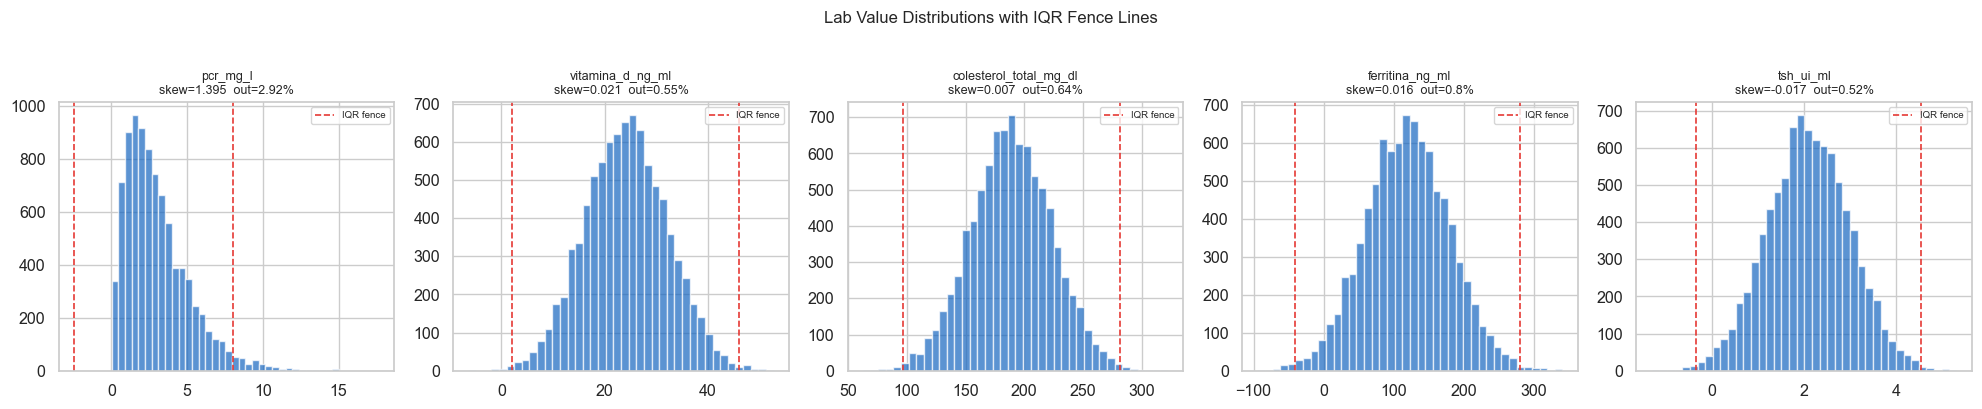

In [98]:
# ── Outlier analysis: lab values ────────────────────────────────────────────
LAB_COLS = [
    'pcr_mg_l', 'vitamina_d_ng_ml', 'colesterol_total_mg_dl',
    'ferritina_ng_ml', 'tsh_ui_ml',
]

rows = []
for col in LAB_COLS:
    s = analysis[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < lo) | (s > hi)).sum()
    rows.append({
        'feature':      col,
        'skewness':     round(s.skew(), 3),
        'outlier_count': int(n_out),
        'outlier_pct':  round(n_out / len(s) * 100, 2),
        'Q1-1.5IQR':    round(lo, 3),
        'Q3+1.5IQR':    round(hi, 3),
    })

outlier_df = pd.DataFrame(rows)
print('Lab value outlier summary:')
print(outlier_df.to_string(index=False))

# ── Recommendation ───────────────────────────────────────────────────────────
needs_robust = outlier_df[(outlier_df['skewness'].abs() > 2) | (outlier_df['outlier_pct'] > 5)]
if len(needs_robust) > 0:
    flagged = ', '.join(needs_robust['feature'].tolist())
    print(f'\nRECOMMENDATION: Use RobustScaler — skewness > 2 or outlier_pct > 5% in: {flagged}')
else:
    print('\nRECOMMENDATION: StandardScaler is acceptable — no feature exceeds skewness > 2 or outlier_pct > 5%')

# ── Histograms with IQR fence lines ─────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, row in zip(axes, rows):
    col = row['feature']
    data = analysis[col].dropna()
    ax.hist(data, bins=40, color='#1565C0', alpha=0.7, edgecolor='white')
    ax.axvline(row['Q1-1.5IQR'], color='#E53935', linestyle='--', linewidth=1.2, label='IQR fence')
    ax.axvline(row['Q3+1.5IQR'], color='#E53935', linestyle='--', linewidth=1.2)
    ax.set_title(f'{col}\nskew={row["skewness"]}  out={row["outlier_pct"]}%', fontsize=9)
    ax.set_xlabel('')
    ax.legend(fontsize=7)
plt.suptitle('Lab Value Distributions with IQR Fence Lines', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 13. Key Findings & Modelling Implications <a id='13'></a>

In [99]:
n_total      = len(all_patients)
n_spiro      = len(analysis)
n_no_spiro   = n_total - n_spiro
n_copd_label = analysis['copd_label'].sum()
n_copd_admin = target_raw['epoc_diagnostico'].sum()
prev_label   = n_copd_label / n_spiro * 100
imbalance    = (n_spiro - n_copd_label) / n_copd_label

print("=" * 68)
print("EDA KEY FINDINGS")
print("=" * 68)
print(f"""
DATASET
  Total patients              : {n_total:,}
  Patients with spirometry    : {n_spiro:,} ({n_spiro/n_total*100:.1f}%)  → training set
  Patients without spirometry : {n_no_spiro:,} ({n_no_spiro/n_total*100:.1f}%)  → inference target

TARGET VARIABLE
  Spirometry label (copd_label): {n_copd_label:,} positive ({prev_label:.1f}%)
  Admin diagnosis (epoc_diag.) : {n_copd_admin:,} positive
  Underdiagnosis captured      : spirometry finds more COPD than admin records
  Class imbalance ratio        : {imbalance:.1f}:1  → SMOTE or class_weight needed

SELECTION BIAS
  Spirometry patients are likely older, sicker, and more symptomatic
  than the full population → check Section 4 output above.
  This MUST be disclosed in the Model Card.

DATA QUALITY
  FEV1/FVC > 1.0 rows          : check Section 2 output (removed before labelling)
  Threshold-crossing patients  : check Section 3 output (confirms MIN ratio rule)
  J44 ICD code                 : EXCLUDE from features (admin encoding of label)
  epoc_diagnostico             : EXCLUDE from features (post-hoc admin record)
  nivel_socioeconomico         : EXCLUDE (healthcare access proxy, not risk factor)
  zona_residencia              : EXCLUDE (same)

STRONGEST PREDICTORS (check Section 11)
  spiro_min_ratio              : primary signal (is the label basis; use carefully)
  spiro_slope                  : decline rate, strong independent signal
  paquetes_ano (pack-years)    : most important non-spirometry feature
  edad (age)                   : consistent positive association
  pcr_mg_l (CRP)               : inflammatory marker
  kw_dyspnea / kw_cough        : NLP signals from clinical notes

MODELLING IMPLICATIONS
  → Training population : patients WITH spirometry only
  → Target             : copd_label = min(FEV1/FVC) < 0.70
  → spiro_min_ratio MUST be excluded from model features
    (it is the basis of the label; using it is leakage)
  → spiro_slope and spiro_n_tests ARE valid features
    (they add longitudinal information beyond the threshold crossing)
  → Consider two-stage architecture:
    Stage 1: no spirometry available, predict risk from demographics/habits/labs/notes
    Stage 2: spirometry available, add longitudinal spiro features
  → Validate performance separately on patients with 1 vs 2+ tests
""")

EDA KEY FINDINGS

DATASET
  Total patients              : 10,000
  Patients with spirometry    : 9,948 (99.5%)  → training set
  Patients without spirometry : 52 (0.5%)  → inference target

TARGET VARIABLE
  Spirometry label (copd_label): 7,600 positive (76.4%)
  Admin diagnosis (epoc_diag.) : 644 positive
  Underdiagnosis captured      : spirometry finds more COPD than admin records
  Class imbalance ratio        : 0.3:1  → SMOTE or class_weight needed

SELECTION BIAS
  Spirometry patients are likely older, sicker, and more symptomatic
  than the full population → check Section 4 output above.
  This MUST be disclosed in the Model Card.

DATA QUALITY
  FEV1/FVC > 1.0 rows          : check Section 2 output (removed before labelling)
  Threshold-crossing patients  : check Section 3 output (confirms MIN ratio rule)
  J44 ICD code                 : EXCLUDE from features (admin encoding of label)
  epoc_diagnostico             : EXCLUDE from features (post-hoc admin record)
  nivel_socioec

---
## Feature Plan: Variable Reference

This table consolidates all variables from the 7 raw tables into three categories.
It serves as the specification for building the feature matrix in `notebooks/02_preprocessing.ipynb`.

---

### A. Original Variables (used as-is)

Raw columns that carry direct clinical signal. They require only imputation and scaling, with no transformation.

| Variable | Source table | Type | Clinical rationale |
|---|---|---|---|
| `edad` | patients | Numeric | Strongest non-spirometry COPD risk factor; risk rises sharply above 60 |
| `sexo` | patients | Categorical | Sex differences in COPD presentation, severity, and historical underdiagnosis in women |
| `imc` | patients | Numeric | Low BMI associated with severity and mortality; high BMI with cardiovascular comorbidities |
| `fumador_actual` | habits | Binary | Current smoking, the primary modifiable COPD risk factor |
| `exfumador` | habits | Binary | Ex-smoking history carries residual airway damage risk |
| `paquetes_ano` | habits | Numeric | Cumulative tobacco dose; dose-response relationship with COPD |
| `actividad_fisica` | habits | Ordinal | Physical inactivity is both a cause and a consequence of COPD |
| `pcr_mg_l` | lab_results | Numeric | Systemic inflammation marker; elevated in active COPD and exacerbations |
| `vitamina_d_ng_ml` | lab_results | Numeric | Deficiency linked to worse lung function and more frequent exacerbations |
| `colesterol_total_mg_dl` | lab_results | Numeric | Cardiovascular comorbidity proxy |
| `ferritina_ng_ml` | lab_results | Numeric | Inflammation and iron-status marker |
| `tsh_ui_ml` | lab_results | Numeric | Thyroid status; hypothyroidism can mimic COPD symptoms |

---

### B. Engineered Features (derived from raw data)

Variables constructed through aggregation, interaction, thresholding, or NLP extraction. None exist in the raw tables.

**Spirometry: longitudinal aggregation** *(from spirometry.csv)*

| Variable | Derivation | Type | Rationale |
|---|---|---|---|
| `spiro_latest_ratio` | FEV1/FVC of the most recent test | Numeric | Current lung function status |
| `spiro_slope` | (last ratio - first ratio) / years span | Numeric | Annual FEV1/FVC decline rate, the strongest disease progression signal |
| `spiro_n_tests` | Count of clean spirometry records | Numeric | Follow-up intensity; proxy for clinical concern level |
| `spiro_years_span` | Days between first and last test / 365.25 | Numeric | Observation window; needed to interpret slope meaningfully |
| `spiro_mean_fev1` | Mean FEV1 across all tests | Numeric | Absolute lung volume; captures severity independently of the ratio |
| `spiro_mean_fvc` | Mean FVC across all tests | Numeric | Differentiates obstructive from restrictive ventilatory patterns |

**Habits and labs: binary flags and interaction terms**

| Variable | Derivation | Type | Rationale |
|---|---|---|---|
| `ever_smoked` | fumador_actual OR exfumador = 1 | Binary | Lifetime tobacco exposure flag |
| `age_x_packyears` | edad x paquetes_ano | Numeric | Interaction: older patients with high tobacco burden carry compounded risk |
| `crp_elevated` | pcr_mg_l > 10 | Binary | Clinically significant systemic inflammation threshold |
| `vitamin_d_deficient` | vitamina_d_ng_ml < 20 | Binary | Deficiency threshold per clinical reference range |

**Clinical events: ICD-10 comorbidity flags** *(from clinical_events.csv)*

| Variable | ICD-10 code | Type | Rationale |
|---|---|---|---|
| `has_asthma` | J45 | Binary | Asthma-COPD overlap syndrome; shared risk factors and frequent diagnostic confusion |
| `has_hypertension` | I10 | Binary | Cardiovascular comorbidity; most common in COPD patients |
| `has_diabetes` | E11 | Binary | Metabolic comorbidity; associated with worse COPD outcomes |
| `has_ihd` | I25 | Binary | Ischaemic heart disease, a frequent COPD comorbidity |
| `has_depression` | F32 | Binary | COPD patients have 2-3x higher depression rates than the general population |
| `n_unique_diag` | Count of distinct ICD codes per patient | Numeric | Overall comorbidity burden |

**Clinical notes: NLP keyword extraction** *(from clinical_notes.csv)*

| Variable | Pattern matched (Spanish) | Type | Rationale |
|---|---|---|---|
| `kw_dyspnea` | disnea, ahogo, falta de aire | Binary | Primary COPD symptom |
| `kw_cough` | tos (crónica) | Binary | Chronic cough, the hallmark symptom |
| `kw_sputum` | esputo, expectoración | Binary | Mucus production; active airway inflammation marker |
| `kw_exacerbation` | exacerbación, agudización | Binary | History of exacerbations, the strongest predictor of COPD severity |
| `kw_breathless` | dificultad respiratoria, disnea de esfuerzo | Binary | Exertional breathlessness; functional impairment indicator |
| `kw_no_symptoms` | sin síntomas, asintomático | Binary | Negative signal: reduces COPD probability |
| `kw_wheezing` | sibilancias, pitidos | Binary | Airway obstruction symptom |
| `keyword_score` | All patterns combined | Numeric | Composite respiratory symptom burden score (0-7) |

---

### C. Variables Excluded from the Main Model

> **Note on `grupo_sanguineo`:** This variable is retained in `features.csv` for a sensitivity analysis but excluded from the main model feature list. See row below for details.

| Variable | Source | Exclusion category | Reason |
|---|---|---|---|
| `nivel_socioeconomico` | patients | **Bias risk** | Healthcare access proxy. Encoding it would teach the model to predict *who gets diagnosed*, not *who has COPD*, perpetuating existing inequities. |
| `zona_residencia` | patients | **Bias risk** | Distance to a spirometry centre predicts diagnosis probability, not disease presence. Same problem. |
| `grupo_sanguineo` | lab_results | **Sensitivity analysis** | Evidence is sparse but not zero. Excluded from the main model. One-hot encoded (`bg_A`, `bg_B`, `bg_AB`; reference = O) and included in `features.csv` for a post-training sensitivity analysis. If AUC delta < 0.01 and SHAP weight is near zero, exclusion from the main model is confirmed empirically. Risk: any observed correlation in synthetic data may be a simulation artefact, not biology. |
| `spiro_min_ratio` | spirometry | **Label leakage** | This is the exact value used to derive `copd_label` (min_ratio < 0.70). Using it as a feature is direct data leakage. |
| `spiro_max_ratio` | spirometry | **Redundant** | Dominated by `spiro_min_ratio`; adds no independent signal given the label definition. |
| `spiro_mean_ratio` | spirometry | **Redundant** | Collinear with `spiro_min_ratio` and `spiro_latest_ratio`. Does not add independent information. |
| `epoc_diagnostico` | target.csv | **Label leakage** | Post-hoc administrative recording. Encodes physician behaviour, partially reflects the true label, and is unavailable at pre-screening time. |
| `has_copd_diag` (J44) | clinical_events | **Label leakage** | ICD-10 J44 is the administrative encoding of the COPD diagnosis, effectively the same information as `epoc_diagnostico`. |
| `kw_copd_mention` | clinical_notes | **Temporal leakage** | Notes explicitly mentioning 'EPOC' or 'enfermedad pulmonar obstructiva' are written after diagnosis; this information is unavailable at pre-screening time. |
| `kw_smoking` | clinical_notes | **Redundant** | Smoking history is already captured with higher precision and completeness in `fumador_actual`, `exfumador`, and `paquetes_ano`. |
| `id_paciente` | all tables | **Identifier** | Row identifier, not a predictive feature. |
| `fecha` (raw dates) | spirometry | **Transformed** | Raw dates carry no direct signal. Their clinical meaning is fully encoded in `spiro_slope` and `spiro_years_span`. |

---

> **Next step**: run `02_preprocessing.ipynb` to build the feature matrix, apply transformations, and save the output files for model training.
